In [ ]:
import pandas as pd
from transformers import pipeline
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sentence_transformers import SentenceTransformer
import umap
import spacy
import numpy as np
import evaluate


In [2]:
df = pd.read_csv('C:\\Users\\marga\\Desktop\\AIEngineering_BBDA\\Hotel-Reviews-Sentiment-Analysis-NLP-Project\\data\\booking_reviews_cleaned.csv')

In [3]:
df.head(1)

,review_title,hotel_name,avg_rating,nationality,rating,review_text,year,month,season,trip_type,traveller_type,stay_length
0,Exceptional,Villa Pura Vida,9.7,Poland,10.0,"Everything was perfect! Quite, cozy place to r...",2021,July,Summer,Business trip,Solo traveller,Stayed 1 night


# using a pre-built sentiment analysis model from Hugging Face (generic)

In [4]:
classifier = pipeline('sentiment-analysis')


[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

In [6]:
# testing on sample lines of the df:

sample_reviews = df['review_text'].sample(5).tolist()

classifier(sample_reviews)

[{'label': 'NEGATIVE', 'score': 0.9621061086654663},
 {'label': 'POSITIVE', 'score': 0.9994972944259644},
 {'label': 'NEGATIVE', 'score': 0.9465890526771545},
 {'label': 'POSITIVE', 'score': 0.9998795986175537},
 {'label': 'POSITIVE', 'score': 0.9980931878089905}]

In [9]:
# for all reviews, with batches, porogress bar and saving results in new columns in df: 

from tqdm.auto import tqdm

texts = df["review_text"].fillna("").astype(str).tolist()

all_results = []

batch_size = 16

for i in tqdm(range(0, len(texts), batch_size)):
    batch = texts[i:i + batch_size]
    
    batch_results = classifier(
        batch,
        truncation=True
    )
    
    all_results.extend(batch_results)

df["transformer_label"] = [result["label"] for result in all_results]
df["transformer_score"] = [result["score"] for result in all_results]

df[["review_text", "rating", "transformer_label", "transformer_score"]].head()

  0%|          | 0/1629 [00:00<?, ?it/s]

,review_text,rating,transformer_label,transformer_score
0,"Everything was perfect! Quite, cozy place to r...",10.0,POSITIVE,0.999868
1,Very friendly host and perfect breakfast!,9.0,POSITIVE,0.999887
2,It was just what we wanted for a week by the b...,10.0,POSITIVE,0.839765
3,My stay in the house was a experiencing bliss ...,10.0,POSITIVE,0.999888
4,The building itself has a very musty smell in ...,9.2,NEGATIVE,0.779410


In [10]:
print("Review text:")
print(df.loc[4, "review_text"])

print("\nRating:")
print(df.loc[4, "rating"])

print("\nTransformer prediction:")
print(df.loc[4, "transformer_label"])

print("\nTransformer confidence:")
print(df.loc[4, "transformer_score"])

Review text:
The building itself has a very musty smell in the hallway (despite being built in 1988), but the apartment itself smells good, which makes it bearable. 
When showering, the hot water goes off every 2-3 minutes for about 20-30 seconds and then only cold water comes out. The hot water then comes back again. This should be checked out. That is the only thing we didn’t like about the apartment. ,

The view was great, the apartment furnished in a modern style and equipped with everything you may need. The apartment was clean. 
There is free, secure parking outside in the building’s parking lot or downstairs in the garage. 
Jan always responded promptly to all messages sent via Booking.com messenger.

Rating:
9.2

Transformer prediction:
NEGATIVE

Transformer confidence:
0.7794097661972046


In [11]:
# Although the review has a high rating, the pretrained transformer classified it as negative because the text contains a complaint about a musty smell. 
# This shows that text-based sentiment can capture specific negative aspects even inside generally positive reviews.

In [13]:
def rating_to_binary_sentiment(rating):
    if rating >= 8:
        return "POSITIVE"
    else:
        return "NEGATIVE"

df["rating_sentiment_binary"] = df["rating"].apply(rating_to_binary_sentiment)

df[["rating", "rating_sentiment_binary", "transformer_label", "transformer_score"]].head(10)

,rating,rating_sentiment_binary,transformer_label,transformer_score
0,10.0,POSITIVE,POSITIVE,0.999868
1,9.0,POSITIVE,POSITIVE,0.999887
2,10.0,POSITIVE,POSITIVE,0.839765
3,10.0,POSITIVE,POSITIVE,0.999888
4,9.2,POSITIVE,NEGATIVE,0.779410
5,10.0,POSITIVE,POSITIVE,0.999774
6,10.0,POSITIVE,POSITIVE,0.999398
7,8.3,POSITIVE,POSITIVE,0.995852
8,9.2,POSITIVE,NEGATIVE,0.998240
9,10.0,POSITIVE,POSITIVE,0.999866


In [14]:
df["rating_sentiment_binary"].value_counts()

rating_sentiment_binary
POSITIVE    19147
NEGATIVE     6909
Name: count, dtype: int64

In [15]:
df["transformer_label"].value_counts()

transformer_label
POSITIVE    13381
NEGATIVE    12675
Name: count, dtype: int64

In [17]:
# classification report:

In [16]:
from sklearn.metrics import classification_report

print(classification_report(
    df["rating_sentiment_binary"],
    df["transformer_label"]
))

              precision    recall  f1-score   support

    NEGATIVE       0.38      0.70      0.49      6909
    POSITIVE       0.84      0.59      0.69     19147

    accuracy                           0.62     26056
   macro avg       0.61      0.64      0.59     26056
weighted avg       0.72      0.62      0.64     26056



In [25]:
# The pretrained transformer achieved **62% agreement** with the rating-based sentiment labels. 
# It performs better on the **POSITIVE** class, with high precision (**0.84**), meaning that when it predicts a review as positive, 
# it usually matches the rating-based label. However, the **NEGATIVE** precision is low (**0.38**), 
# which means many reviews predicted as negative actually have high ratings. 

# This may happen because hotel reviews often contain mixed feedback: 
# a guest can give a high score overall while still mentioning negative details such as smell, noise, cleanliness, or breakfast issues.
#  Therefore, the disagreement between rating-based sentiment and transformer sentiment is useful, because it can reveal hidden complaints inside otherwise positive reviews.
 
#  This pretrained transformer is a good first baseline, but the next step should be comparing it with classical ML models and later fine-tuning a transformer on this specific dataset.

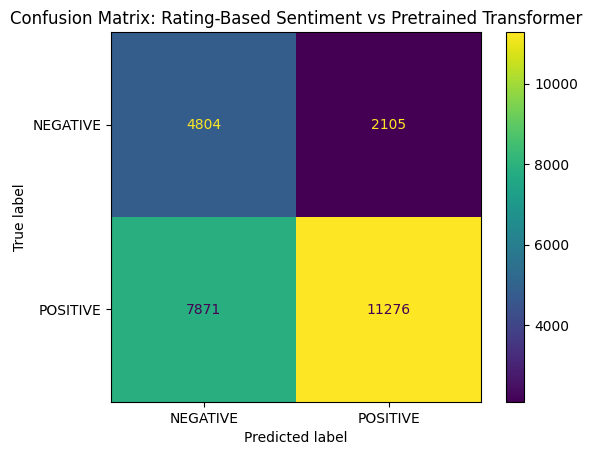

In [18]:
# Confusion matrix:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ["NEGATIVE", "POSITIVE"]

cm = confusion_matrix(
    df["rating_sentiment_binary"],
    df["transformer_label"],
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot()
plt.title("Confusion Matrix: Rating-Based Sentiment vs Pretrained Transformer")
plt.show()



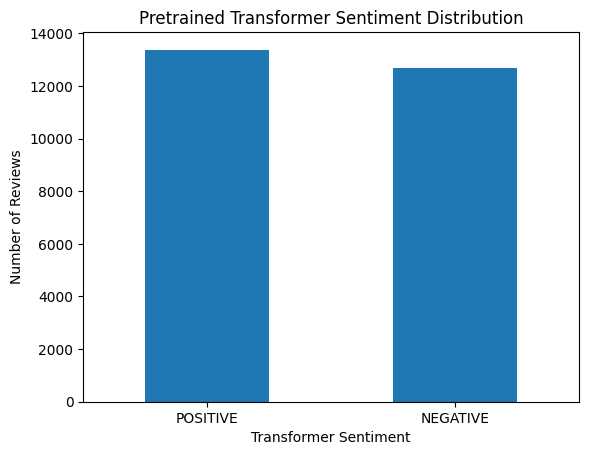

In [19]:
df["transformer_label"].value_counts().plot(kind="bar")

plt.title("Pretrained Transformer Sentiment Distribution")
plt.xlabel("Transformer Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

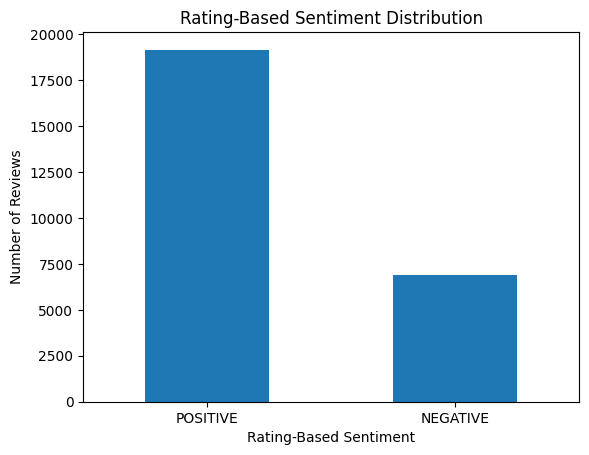

In [20]:
df["rating_sentiment_binary"].value_counts().plot(kind="bar")

plt.title("Rating-Based Sentiment Distribution")
plt.xlabel("Rating-Based Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

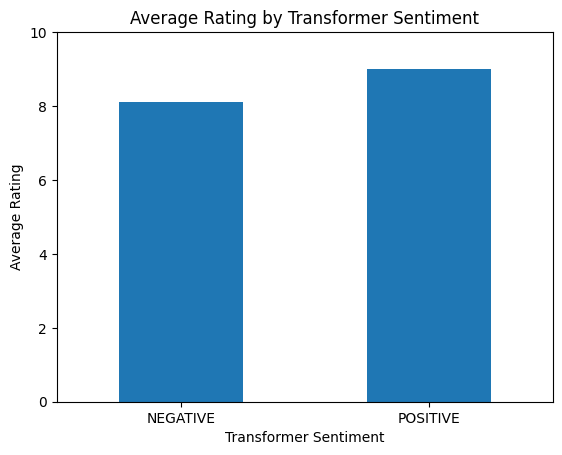

In [21]:
avg_rating_by_transformer = df.groupby("transformer_label")["rating"].mean()

avg_rating_by_transformer.plot(kind="bar")

plt.title("Average Rating by Transformer Sentiment")
plt.xlabel("Transformer Sentiment")
plt.ylabel("Average Rating")
plt.ylim(0, 10)
plt.xticks(rotation=0)
plt.show()

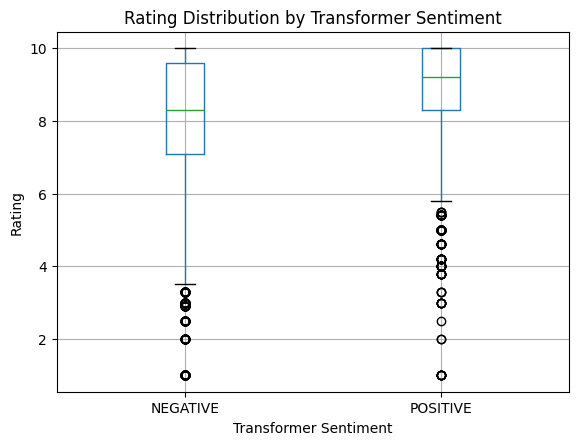

In [22]:
df.boxplot(column="rating", by="transformer_label")

plt.title("Rating Distribution by Transformer Sentiment")
plt.suptitle("")
plt.xlabel("Transformer Sentiment")
plt.ylabel("Rating")
plt.show()

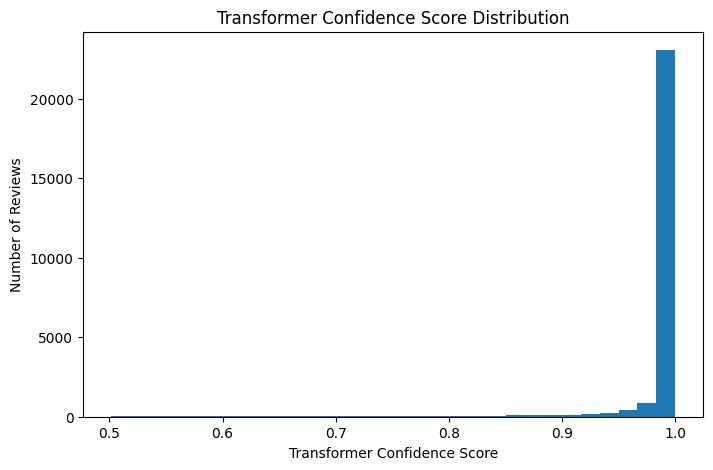

In [23]:
plt.figure(figsize=(8, 5))

plt.hist(df["transformer_score"], bins=30)

plt.title("Transformer Confidence Score Distribution")
plt.xlabel("Transformer Confidence Score")
plt.ylabel("Number of Reviews")
plt.show()

# Using specifc Pre-Trained Transformer:

In [26]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

model_name = "nlptown/bert-base-multilingual-uncased-sentiment"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

star_classifier = pipeline("sentiment-analysis",model=model,tokenizer=tokenizer)

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [28]:
# this model is better, so we get more ratings, not just positive-negative

In [27]:
star_classifier(df["review_text"].iloc[0], truncation=True)

[{'label': '5 stars', 'score': 0.7167595028877258}]

In [29]:
sample_texts = df["review_text"].head(10).tolist()

star_classifier(sample_texts, truncation=True)

[{'label': '5 stars', 'score': 0.7167595028877258},
 {'label': '5 stars', 'score': 0.8368703126907349},
 {'label': '5 stars', 'score': 0.6667758226394653},
 {'label': '5 stars', 'score': 0.8031072020530701},
 {'label': '3 stars', 'score': 0.3947681784629822},
 {'label': '5 stars', 'score': 0.9215629696846008},
 {'label': '4 stars', 'score': 0.4999958872795105},
 {'label': '5 stars', 'score': 0.47173967957496643},
 {'label': '1 star', 'score': 0.44656816124916077},
 {'label': '5 stars', 'score': 0.8680040240287781}]

In [30]:
from tqdm.auto import tqdm

texts = df["review_text"].fillna("").astype(str).tolist()

star_results = []
batch_size = 16

for i in tqdm(range(0, len(texts), batch_size)):
    batch = texts[i:i + batch_size]
    
    batch_results = star_classifier(
        batch,
        truncation=True
    )
    
    star_results.extend(batch_results)

df["star_transformer_label"] = [r["label"] for r in star_results]
df["star_transformer_score"] = [r["score"] for r in star_results]

df.to_csv("../data/booking_reviews_with_two_transformer_predictions.csv", index=False)

  0%|          | 0/1629 [00:00<?, ?it/s]

In [ ]:
df['star_transformer_label'][''].head(10)

,review_title,hotel_name,avg_rating,nationality,rating,review_text,year,month,season,trip_type,traveller_type,stay_length,transformer_label,transformer_score,rating_sentiment_binary,star_transformer_label,star_transformer_score
0,Exceptional,Villa Pura Vida,9.7,Poland,10.0,"Everything was perfect! Quite, cozy place to r...",2021,July,Summer,Business trip,Solo traveller,Stayed 1 night,POSITIVE,0.999868,POSITIVE,5 stars,0.716760
1,I highly recommend this b&b! We enjoyed it a lot!,Villa Pura Vida,9.7,Belgium,9.0,Very friendly host and perfect breakfast!,2019,November,Autumn,Leisure trip,Couple,Stayed 1 night,POSITIVE,0.999887,POSITIVE,5 stars,0.836870
2,Exceptional,Hydro Palace Apartment,9.2,United Kingdom,10.0,It was just what we wanted for a week by the b...,2020,January,Winter,Leisure trip,Couple,Stayed 6 nights,POSITIVE,0.839765,POSITIVE,5 stars,0.666776
3,My stay in the house was a experiencing bliss ...,Villa Pura Vida,9.7,Netherlands,10.0,My stay in the house was a experiencing bliss ...,2019,September,Autumn,Business trip,Solo traveller,Stayed 4 nights,POSITIVE,0.999888,POSITIVE,5 stars,0.803107
4,One bedroom apartment with wonderful view and ...,Hydro Palace Apartment,9.2,South Africa,9.2,The building itself has a very musty smell in ...,2019,June,Summer,Leisure trip,People with friends,Stayed 4 nights,NEGATIVE,0.779410,POSITIVE,3 stars,0.394768
5,Fantastic! Beautiful home with a gracious welc...,Villa Pura Vida,9.7,United Kingdom,10.0,"Nothing,\n\nBeautiful home! Great room, most c...",2019,June,Summer,Business trip,Couple,Stayed 1 night,POSITIVE,0.999774,POSITIVE,5 stars,0.921563
6,"everything perfect, great bath in the room!",Love Nest Versailles - Unique Louis XIV decora...,8.8,Poland,10.0,to many messages sending from the owner in the...,2021,June,Summer,Business trip,Couple,Stayed 1 night,POSITIVE,0.999398,POSITIVE,4 stars,0.499996
7,Very good,Gite Namaste,9.3,Netherlands,8.3,"Spacious, more than enough rooms, a lot of bat...",2019,August,Summer,Leisure trip,Family with young children,Stayed 7 nights,POSITIVE,0.995852,POSITIVE,5 stars,0.471740
8,Superb,Hydro Palace Apartment,9.2,United Kingdom,9.2,There are no comments available for this review,2019,March,Spring,Leisure trip,Couple,Stayed 3 nights,NEGATIVE,0.998240,POSITIVE,1 star,0.446568
9,highly recommended,Villa Pura Vida,9.7,United States,10.0,"nothing -- place was perfect,\n\nThis is an ex...",2019,June,Summer,Business trip,Group,Stayed 1 night,POSITIVE,0.999866,POSITIVE,5 stars,0.868004


In [33]:
def rating_to_5_star_label(rating):
    if rating <= 2:
        return "1 star"
    elif rating <= 4:
        return "2 stars"
    elif rating <= 6:
        return "3 stars"
    elif rating <= 8:
        return "4 stars"
    else:
        return "5 stars"

df["rating_5_star_label"] = df["rating"].apply(rating_to_5_star_label)

df[[
    "rating",
    "rating_5_star_label",
    "star_transformer_label",
    "star_transformer_score"
]].head(10)

,rating,rating_5_star_label,star_transformer_label,star_transformer_score
0,10.0,5 stars,5 stars,0.716760
1,9.0,5 stars,5 stars,0.836870
2,10.0,5 stars,5 stars,0.666776
3,10.0,5 stars,5 stars,0.803107
4,9.2,5 stars,3 stars,0.394768
5,10.0,5 stars,5 stars,0.921563
6,10.0,5 stars,4 stars,0.499996
7,8.3,5 stars,5 stars,0.471740
8,9.2,5 stars,1 star,0.446568
9,10.0,5 stars,5 stars,0.868004


In [34]:
# This table compares the original hotel rating, converted into a 1–5 star label, with the specific pretrained transformer’s predicted star label. 
# When both labels match, the review text and the numerical rating express similar sentiment. 
# When they disagree, it means the written review sounds different from the final rating. 
# For example, some reviews have very high ratings but receive lower transformer star predictions because the text contains complaints or mixed feedback. 
# These disagreement cases are useful because they can reveal hidden negative issues inside otherwise positive reviews.

In [35]:
star_prediction_summary = df["star_transformer_label"].value_counts().sort_index().reset_index()
star_prediction_summary.columns = ["star_transformer_label", "count"]

star_prediction_summary["percentage"] = (
    star_prediction_summary["count"] / len(df) * 100
).round(2)

star_prediction_summary

,star_transformer_label,count,percentage
0,1 star,8840,33.93
1,2 stars,2175,8.35
2,3 stars,3003,11.53
3,4 stars,5179,19.88
4,5 stars,6859,26.32


In [36]:
# rating-derived labels:

rating_5_star_summary = df["rating_5_star_label"].value_counts().sort_index().reset_index()
rating_5_star_summary.columns = ["rating_5_star_label", "count"]

rating_5_star_summary["percentage"] = (
    rating_5_star_summary["count"] / len(df) * 100
).round(2)

rating_5_star_summary

,rating_5_star_label,count,percentage
0,1 star,138,0.53
1,2 stars,420,1.61
2,3 stars,1466,5.63
3,4 stars,6960,26.71
4,5 stars,17072,65.52


In [37]:
# classification for specific transformer:

from sklearn.metrics import classification_report

labels = ["1 star", "2 stars", "3 stars", "4 stars", "5 stars"]

print(classification_report(
    df["rating_5_star_label"],
    df["star_transformer_label"],
    labels=labels,
    zero_division=0
))

              precision    recall  f1-score   support

      1 star       0.01      0.70      0.02       138
     2 stars       0.06      0.34      0.11       420
     3 stars       0.09      0.18      0.12      1466
     4 stars       0.29      0.21      0.24      6960
     5 stars       0.89      0.36      0.51     17072

    accuracy                           0.31     26056
   macro avg       0.27      0.36      0.20     26056
weighted avg       0.66      0.31      0.41     26056



In [38]:
#The specific pretrained transformer achieved **31% exact agreement** with the rating-derived 1–5 star labels. 
# This is much lower than the binary transformer comparison, but it is also a much harder task because the model must 
# predict the exact star category instead of only positive/negative sentiment. 
# The dataset is also highly imbalanced: most real ratings are converted to **5 stars** because hotel reviews are generally very positive. 
# The model performs best on the **5 stars** class, with high precision (**0.89**), meaning that when it predicts 5 stars, 
# it often matches the rating-derived label. However, recall for 5 stars is only **0.36**, meaning it misses many reviews that users rated very highly. 
# For the lower star classes, performance is weak, mostly because there are very few true examples and because written reviews often contain mixed feedback. 
# Overall, this model is useful as a second pretrained baseline and gives more detailed sentiment levels than the binary model, 
# but exact 1–5 star prediction is difficult without fine-tuning on this specific hotel review dataset.

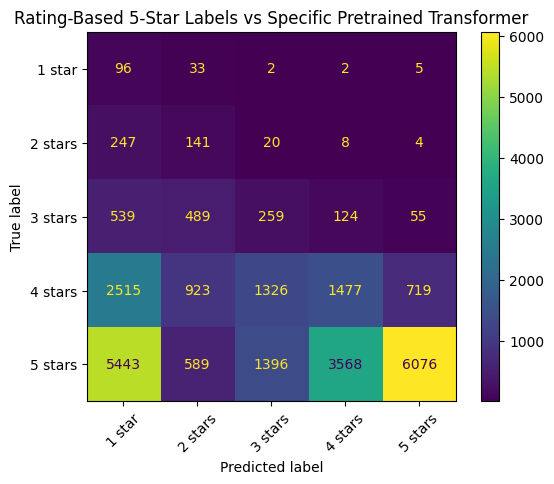

In [39]:
# confusion matrix: 

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ["1 star", "2 stars", "3 stars", "4 stars", "5 stars"]

cm = confusion_matrix(
    df["rating_5_star_label"],
    df["star_transformer_label"],
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot()
plt.title("Rating-Based 5-Star Labels vs Specific Pretrained Transformer")
plt.xticks(rotation=45)
plt.show()

In [43]:
# comparing specific transformer to the binary transformer, by converting firstly:

def star_label_to_binary(label):
    if label in ["4 stars", "5 stars"]:
        return "POSITIVE"
    else:
        return "NEGATIVE"

df["star_transformer_binary"] = df["star_transformer_label"].apply(star_label_to_binary)

# comparing with th ecrosstab:

pd.crosstab(
    df["transformer_label"],
    df["star_transformer_binary"],
    rownames=["Default Transformer"],
    colnames=["Specific Star Transformer as Binary"]
)

Specific Star Transformer as Binary,NEGATIVE,POSITIVE
Default Transformer,,
NEGATIVE,11645,1030
POSITIVE,2373,11008


In [44]:
# classification report for these two: 

from sklearn.metrics import classification_report

print(classification_report(
    df["transformer_label"],
    df["star_transformer_binary"],
    labels=["NEGATIVE", "POSITIVE"],
    zero_division=0
))

              precision    recall  f1-score   support

    NEGATIVE       0.83      0.92      0.87     12675
    POSITIVE       0.91      0.82      0.87     13381

    accuracy                           0.87     26056
   macro avg       0.87      0.87      0.87     26056
weighted avg       0.87      0.87      0.87     26056



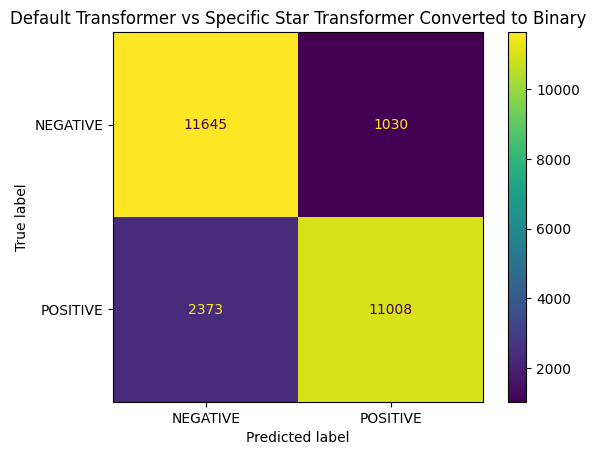

In [46]:
# and their confusion matrix:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ["NEGATIVE", "POSITIVE"]

cm = confusion_matrix(
    df["transformer_label"],
    df["star_transformer_binary"],
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot()
plt.title("Default Transformer vs Specific Star Transformer Converted to Binary")
plt.show()

In [47]:
# The specific 5-star transformer was also converted into a binary sentiment label, where 4–5 stars are considered POSITIVE and 1–3 stars are considered NEGATIVE. 
# This allows a direct comparison with the previous default transformer, which only predicts POSITIVE or NEGATIVE.
# This comparison does not measure accuracy against a true ground truth label. 
# Instead, it shows how similarly the two pretrained transformer models interpret the same review text. 
# If they disagree, it may indicate that the default binary model and the review-specific star model are sensitive to different aspects of the text.

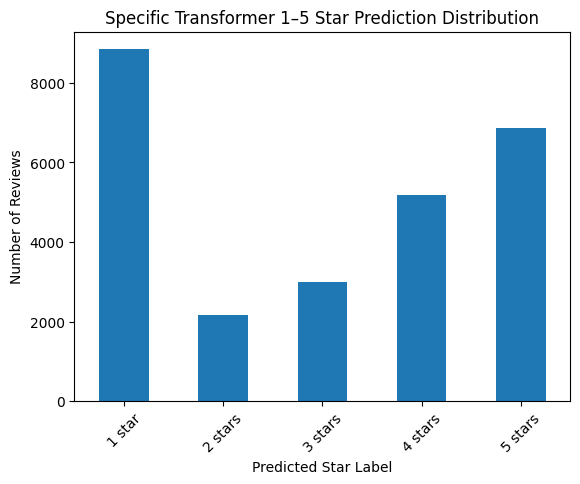

In [49]:
# Plot 1 — Specific transformer star prediction distribution

df["star_transformer_label"].value_counts().sort_index().plot(kind="bar")

plt.title("Specific Transformer 1–5 Star Prediction Distribution")
plt.xlabel("Predicted Star Label")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.show()

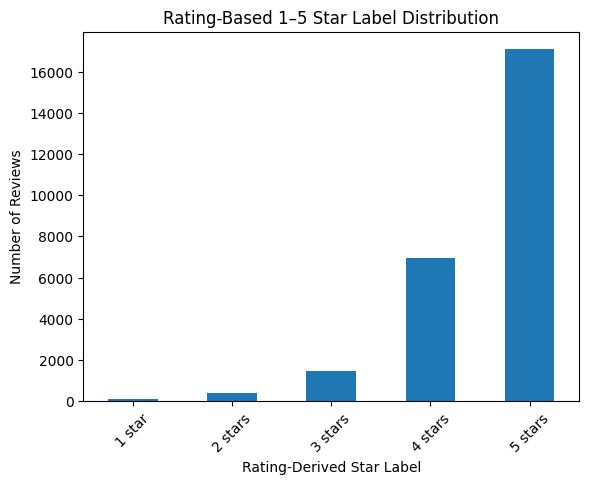

In [50]:
# Plot 2 — Rating-derived 5-star distribution  (what users rated vs what the transformer predicted from text)

df["rating_5_star_label"].value_counts().sort_index().plot(kind="bar")

plt.title("Rating-Based 1–5 Star Label Distribution")
plt.xlabel("Rating-Derived Star Label")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.show()

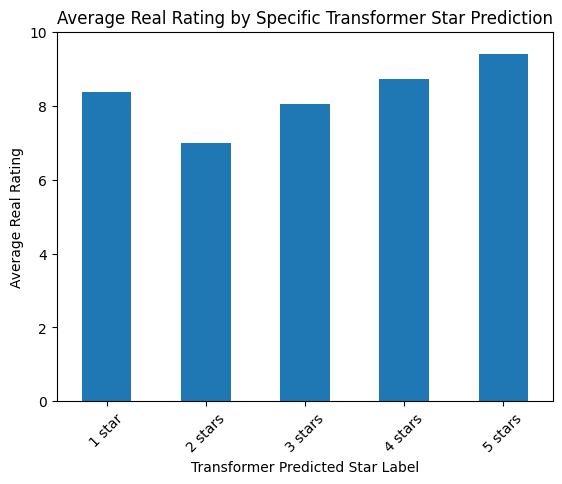

In [51]:
# Plot 3 — Average real rating by transformer star prediction

avg_rating_by_star_prediction = (
    df.groupby("star_transformer_label")["rating"]
    .mean()
    .reindex(["1 star", "2 stars", "3 stars", "4 stars", "5 stars"])
)

avg_rating_by_star_prediction.plot(kind="bar")

plt.title("Average Real Rating by Specific Transformer Star Prediction")
plt.xlabel("Transformer Predicted Star Label")
plt.ylabel("Average Real Rating")
plt.ylim(0, 10)
plt.xticks(rotation=45)
plt.show()

In [52]:
# High real rating but low transformer star prediction

high_rating_low_star = df[
    (df["rating"] >= 8) &
    (df["star_transformer_label"].isin(["1 star", "2 stars", "3 stars"]))
].copy()

high_rating_low_star[
    ["review_text", "rating", "star_transformer_label", "star_transformer_score"]
].sort_values("star_transformer_score", ascending=False).head(20)

,review_text,rating,star_transformer_label,star_transformer_score
12325,"Very cold and it is turkish 3 stars,\n\nClean ...",8.0,3 stars,0.979278
14294,"?,\n\n1 star michelin guide for etape menu!",10.0,1 star,0.972643
24877,"There is nothing to say, except the buffet bre...",8.8,3 stars,0.972001
10598,"Nothing! Our visit was amazing.,\n\nEverything...",10.0,3 stars,0.970938
11507,Can’t call reception from the room !! What a h...,8.8,3 stars,0.947911
8163,My only caution would be if you stay on the t...,9.6,2 stars,0.909427
191,I think the price was too high for a 3 stars h...,8.0,3 stars,0.906963
25483,"Absolutely nothing,\n\nEverything",9.6,1 star,0.904524
17901,"Nothing,\n\nAbsolutely everything",10.0,1 star,0.890417
19872,I really liked the location of the property. I...,9.2,3 stars,0.879015


In [53]:
# Low real rating but high transformer star prediction

low_rating_high_star = df[
    (df["rating"] < 8) &
    (df["star_transformer_label"].isin(["4 stars", "5 stars"]))
].copy()

low_rating_high_star[
    ["review_text", "rating", "star_transformer_label", "star_transformer_score"]
].sort_values("star_transformer_score", ascending=False).head(20)

,review_text,rating,star_transformer_label,star_transformer_score
1831,staffs are accomodating! classic & classy! rea...,7.5,5 stars,0.977585
1731,"Liked absolutely everything.,\n\nLovely consie...",7.5,5 stars,0.918081
14571,"Excellent breakfast, amazing restaurant.",7.0,5 stars,0.912870
8974,Fantastic location on the Great Market. Great ...,7.9,5 stars,0.908784
1312,"Dated decor,\n\nClean, comfortable, spacious, ...",7.9,5 stars,0.908776
15531,Excellent breakfast and fantastic location.,7.9,5 stars,0.902968
19316,"Nothing at all. Everything was perfect,\n\nAl...",7.5,5 stars,0.896558
20205,"It was very clean hotel, 20min wall from the m...",7.5,5 stars,0.889764
277,Our room was nice but felt like it was an afte...,7.5,4 stars,0.881579
16401,perfect location just at city center. ground f...,7.9,5 stars,0.880310


In [54]:
df.to_csv("../data/booking_reviews_with_two_transformer_predictions.csv", index=False)

In [55]:
# now we have the new df with the new columns of the two trasnformers plotted: 

df = pd.read_csv("../data/booking_reviews_with_two_transformer_predictions.csv")

In [56]:
# ## Specific Pretrained Transformer Report

# A second pretrained transformer model was tested: `nlptown/bert-base-multilingual-uncased-sentiment`. 
# Unlike the default sentiment pipeline, this model predicts review sentiment as star ratings from 1 to 5. 
# This makes it more relevant for hotel review analysis because the original dataset also contains numerical guest ratings.

# To evaluate the model, the original 1–10 hotel ratings were converted into 1–5 star labels and compared with the transformer’s predicted star labels. 
# The comparison is not a perfect ground truth evaluation, because the rating is an overall user score while the transformer only reads the written text. 
# However, it helps measure how closely the text-based prediction matches the user’s rating behavior.

# The model can also be converted into a binary sentiment label by treating 4–5 stars as positive and 1–3 stars as negative. 
# This allows direct comparison with the earlier default transformer pipeline. Disagreement cases are especially useful, because they may reveal reviews 
# where guests gave a high rating but still mentioned negative details in the text.